In [1]:
import numpy as np
from scipy.integrate import solve_ivp, dblquad
import matplotlib.pyplot as plt
from numba import jit
import logging

# Constants
w_0 = 5
n_0 = 1.000277
z_w = 50
alpha = 0.002
dndT = -7.7 * 10**(-4) / 770 * 0.002
gamma = 0.5
n = n_0
xi = 1
rho = 1.225
c_rho = 1005
kappa = 0.025
alpha_loss = 0.01

# Initial conditions
C_0 = 100
W_x_0 = W_y_0 = (w_0 * np.sqrt(n_0 * alpha)) / (np.sqrt(w_0**4 + (0 - z_w)**2))
T_x_0 = T_y_0 = 0
X_0 = Y_0 = 0
F_x_0 = F_y_0 = (-0.5 * n_0 * alpha * (0 - z_w)) / (w_0**4 + (0 - z_w)**2)
P_0 = np.arctan(z_w / w_0**2)

resolution = 15
x_cor = np.linspace(-10, 10, resolution)
y_cor = np.linspace(-10, 10, resolution)
x_grid, y_grid = np.meshgrid(x_cor, y_cor)

# Initialize the state vector
y = np.array([C_0, W_x_0, W_y_0, T_x_0, T_y_0, X_0, Y_0, F_x_0, F_y_0, P_0])
z_range = (0, 10000)
num_iterations = 15
delta_z = 1000
z_steps = np.arange(z_range[0], z_range[1] + delta_z, delta_z)

logging.basicConfig(level=logging.INFO)

@jit
def heat_profile(system, x_grid, y_grid, dndT, resolution):
    C, W_x, W_y, T_x, T_y, X, Y, F_x, F_y, P = system
    T = np.zeros_like(x_grid)
    for i in range(resolution):
        for j in range(resolution):
            T[i, j] = solve_heat_equation(x_grid[i, j], y_grid[i, j], X, Y, W_x, W_y)
    return -dndT * T

def solve_heat_equation(x, y, X, Y, W_x, W_y):
    limit_factor = 3
    def integrand(x_prime, y_prime):
        r_squared = (x - x_prime)**2 + (y - y_prime)**2
        gaussian = np.exp(-W_x**2 * (x_prime - X)**2) * np.exp(-W_y**2 * (y_prime - Y)**2)
        return 0.5 * np.log(r_squared + 1e-10) * gaussian
    a, b = X - limit_factor * W_x, X + limit_factor * W_x
    c, d = Y - limit_factor * W_y, Y + limit_factor * W_y
    result, _ = dblquad(integrand, a, b, lambda _: c, lambda _: d)
    return result

def transverse_integral(turb_grid, mode_function, x_grid, y_grid, upsilon):
    vectorized_mode_function = np.vectorize(mode_function)
    mode_grid = vectorized_mode_function(x_grid, y_grid)
    product = turb_grid * mode_grid
    dx = (x_cor[1] - x_cor[0])
    dy = (y_cor[1] - y_cor[0])
    return np.sum(product) * dx * dy * upsilon

def beam_system(z, y, delta_n_thermal):
    C, W_x, W_y, T_x, T_y, X, Y, F_x, F_y, P = y
    upsilon = (1 / (2 * np.pi)) * (1 / kappa) * ((alpha / (rho * c_rho)) * C**2 * (W_x * W_y) / np.pi * np.exp(-alpha_loss * z))
    return [
        0,
        (2 / (n * xi)) * F_x * W_x,
        (2 / (n * xi)) * F_y * W_y,
        -n * gamma**2 * transverse_integral(delta_n_thermal, lambda x, y: 4 * W_x**2 * (x - X) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        -n * gamma**2 * transverse_integral(delta_n_thermal, lambda x, y: 4 * W_y**2 * (y - Y) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        -2 * T_x,
        -2 * T_y,
        (-W_x**4 / (2 * n * xi)) + (2 * F_x**2 / (n * xi)) + (gamma**2 / xi) * transverse_integral(delta_n_thermal, lambda x, y: W_x**2 * (1 - 2 * W_x**2 * (x - X)) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        (-W_y**4 / (2 * n * xi)) + (2 * F_y**2 / (n * xi)) + (gamma**2 / xi) * transverse_integral(delta_n_thermal, lambda x, y: W_y**2 * (1 - 2 * W_y**2 * (y - Y)) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        ((W_x**2 + W_y**2) / (2 * n * xi)) - (gamma**2 / xi) * transverse_integral(delta_n_thermal, lambda x, y: (2 - W_x**2 * (x - X)**2 - W_y**2 * (y - Y)**2) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon)
    ]

def process_segment(iteration, z_start, z_end, y_current, segment_results, thermal_results, overlap=0.1):
    """
    Process each segment with consideration for overlap with the previous segment's end state.
    Args:
        iteration (int): The current iteration count.
        z_start (float): The start of the current segment.
        z_end (float): The end of the current segment.
        y_current (np.array): The state vector at the start of the segment.
        segment_results (list): Collection of results for this iteration.
        thermal_results (list): Collection of thermal profiles.
        overlap (float): Percentage of the segment to overlap with the previous segment.
    """
    # Calculate the effective start considering overlap
    segment_length = z_end - z_start
    effective_z_start = max(z_start - segment_length * overlap, 0)
    recalibration_needed = effective_z_start != z_start

    logging.info(f"Iteration {iteration + 1}: Processing segment from {effective_z_start} to {z_end}")

    # Calculate the thermal profile at the start of the segment
    delta_n_thermal = heat_profile(y_current, x_grid, y_grid, dndT, resolution)
    thermal_results.append(delta_n_thermal)

    # Recalibrate initial conditions if necessary
    if recalibration_needed:
        recalibration_steps = 100
        t_eval_recalibration = np.linspace(effective_z_start, z_start, recalibration_steps)
        recalibration_result = solve_ivp(
            lambda z, y: beam_system(z, y, delta_n_thermal),
            [effective_z_start, z_start],
            y_current,
            method='RK45',
            t_eval=t_eval_recalibration
        )

        if recalibration_result.success:
            y_current = recalibration_result.y[:, -1]
        else:
            logging.warning(f"Recalibration failed from z={effective_z_start} to z={z_start}")

    # Solve the beam system over the main segment
    t_eval_main = np.linspace(z_start, z_end, 100)
    sol = solve_ivp(
        lambda z, y: beam_system(z, y, delta_n_thermal),
        [z_start, z_end],
        y_current,
        method='RK45',
        t_eval=t_eval_main
    )

    if sol.success:
        segment_results.append(sol.y)
        y_current[:] = sol.y[:, -1]
    else:
        logging.error(f"ODE solver failed to converge for segment from z={z_start} to {z_end}")

    # Return updated state
    return y_current

def run_simulation():
    y_current = y.copy()
    optical_results = []
    thermal_results = []

    for i in range(num_iterations):
        logging.info(f"Starting iteration {i + 1}/{num_iterations}")
        iteration_results = []

        for z_start, z_end in zip(z_steps[:-1], z_steps[1:]):
            y_current = process_segment(i, z_start, z_end, y_current, iteration_results, thermal_results)

        optical_results.append(iteration_results)
        y_current = iteration_results[-1][:, -1]

    logging.info("Simulation completed.")    
    return optical_results, thermal_results

optical_results, thermal_results = run_simulation()


INFO:root:Starting iteration 1/15
INFO:root:Iteration 1: Processing segment from 0 to 1000
<ipython-input-1-2d7d5629dfa0>:43: NumbaWarning: 
Compilation is falling back to object mode WITH looplifting enabled because Function "heat_profile" failed type inference due to: Untyped global name 'solve_heat_equation': Cannot determine Numba type of <class 'function'>

File "<ipython-input-1-2d7d5629dfa0>", line 49:
def heat_profile(system, x_grid, y_grid, dndT, resolution):
    <source elided>
        for j in range(resolution):
            T[i, j] = solve_heat_equation(x_grid[i, j], y_grid[i, j], X, Y, W_x, W_y)
            ^

  @jit
INFO:numba.core.transforms:finding looplift candidates
<ipython-input-1-2d7d5629dfa0>:43: NumbaWarning: 
Compilation is falling back to object mode WITHOUT looplifting enabled because Function "heat_profile" failed type inference due to: Cannot determine Numba type of <class 'numba.core.dispatcher.LiftedLoop'>

File "<ipython-input-1-2d7d5629dfa0>", line 47:
de

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def plot_beam_widths(optical_results, z_range):
    # Create figure for plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    line_wx, = ax.plot([], [], label='W_x', color='r')
    line_wy, = ax.plot([], [], label='W_y', color='b', linestyle='dashed')
    ax.set_title('Beam Widths W_x and W_y Over Propagation')
    ax.set_xlabel('Propagation Distance z')
    ax.set_ylabel('Widths W_x and W_y')
    ax.legend()
    ax.grid(True)
    ax.set_xlim(z_range)
    ax.set_ylim([0, max([max(segment[1,:]) for iteration in optical_results for segment in iteration] +
                        [max(segment[2,:]) for iteration in optical_results for segment in iteration]) * 1.1])

    def animate(i):
        z_values = []
        W_x_values = []
        W_y_values = []
        current_z = z_range[0]
        delta_z = (z_range[1] - z_range[0]) / len(optical_results[i])

        for segment_result in optical_results[i]:
            # Calculate z-values for the current segment
            num_points = segment_result.shape[1]
            z_segment = np.linspace(current_z, current_z + delta_z, num_points)
            z_values.extend(z_segment)
            current_z += delta_z

            # Extract W_x and W_y values
            W_x_values.extend(segment_result[1, :])
            W_y_values.extend(segment_result[2, :])

        # Update plot data
        line_wx.set_data(z_values, W_x_values)
        line_wy.set_data(z_values, W_y_values)
        return line_wx, line_wy

    # Create animation
    ani = FuncAnimation(fig, animate, frames=len(optical_results), interval=1000, blit=True)
    plt.close(fig)  # Close static figure to prevent double display
    return HTML(ani.to_jshtml())  # Display as HTML

# Assuming optical_results is populated with the correct structure
html_animation = plot_beam_widths(optical_results, z_range)
display(html_animation)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


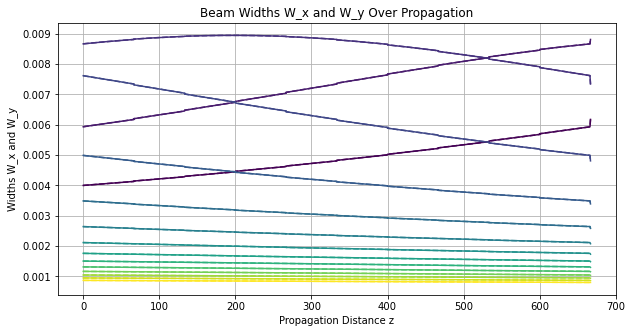

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_beam_widths(optical_results, z_range):
    plt.figure(figsize=(10, 5))

    colors = plt.cm.viridis(np.linspace(0, 1, len(optical_results)))  # Generate a color map for iterations

    current_z = z_range[0]
    delta_z = (z_range[1] - z_range[0]) / sum(len(iteration_result) for iteration_result in optical_results)

    # Iterate through each iteration's results
    for iteration_index, iteration_result in enumerate(optical_results):
        z_values = []
        W_x_values = []
        W_y_values = []
        current_iteration_z = current_z  # Start z for this iteration

        # Iterate through each segment's result in this iteration
        for segment_result in iteration_result:
            segment_length = len(segment_result[1, :])
            z_segment = np.linspace(current_iteration_z, current_iteration_z + delta_z, segment_length)
            z_values.extend(z_segment)
            W_x_values.extend(segment_result[1, :])  # Assuming index 1 is W_x in results
            W_y_values.extend(segment_result[2, :])  # Assuming index 2 is W_y in results
            current_iteration_z += delta_z  # Update z for the next segment

        # Plot this iteration's results
        plt.plot(z_values, W_x_values, label=f'W_x Iteration {iteration_index+1}', color=colors[iteration_index])
        plt.plot(z_values, W_y_values, label=f'W_y Iteration {iteration_index+1}', linestyle='dashed', color=colors[iteration_index])

    plt.title('Beam Widths W_x and W_y Over Propagation')
    plt.xlabel('Propagation Distance z')
    plt.ylabel('Widths W_x and W_y')
#     plt.legend()
    plt.grid(True)
    plt.show()

# Assuming optical_results is populated with the correct structure
plot_beam_widths(optical_results, z_range)


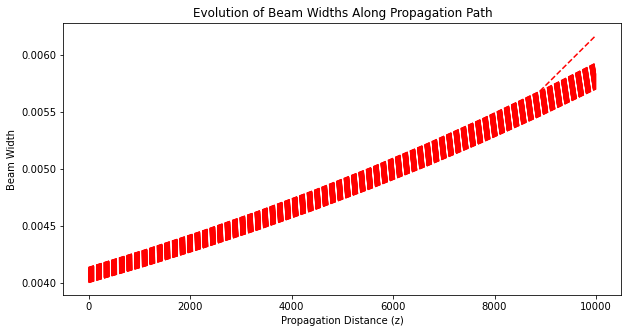

In [4]:
import matplotlib.pyplot as plt

def plot_diagnostics(optical_results, z_range):
    # Assuming the optical_results contain [W_x, W_y, ..., other parameters]
    # Extract W_x and W_y for the latest iteration only for simplicity
    W_x = [result[1] for result in optical_results[0]]  # Last iteration, all W_x
    W_y = [result[2] for result in optical_results[0]]  # Last iteration, all W_y
    z_values = np.linspace(z_range[0], z_range[1], len(W_x))

    plt.figure(figsize=(10, 5))
    plt.plot(z_values, W_x, label='Width W_x', color='red', linestyle='dashed')
#     plt.plot(z_values, W_y, label='Width W_y', color='blue')
    plt.title('Evolution of Beam Widths Along Propagation Path')
    plt.xlabel('Propagation Distance (z)')
    plt.ylabel('Beam Width')
#     plt.legend()
#     plt.grid(True)
    plt.show()

# Call this function with the latest optical results and your z_range
plot_diagnostics(optical_results, (0, 10000))


In [5]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_heat_maps(thermal_results):
    fig, ax = plt.subplots(figsize=(8, 6))
    cax = ax.imshow(thermal_results[0], cmap='hot', origin='lower')
    fig.colorbar(cax, ax=ax)
    ax.set_title('Heat Profile Over Time')
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')

    def update(frame):
        cax.set_data(thermal_results[frame])
        return cax,

    ani = FuncAnimation(fig, update, frames=len(thermal_results), interval=200, blit=True)
    plt.close(fig)  # Close static figure to prevent double display
    return HTML(ani.to_jshtml())

html_animation = animate_heat_maps(thermal_results)
display(html_animation)


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_beam_widths(optical_results, z_range):
    fig, ax = plt.subplots(figsize=(15, 5))
    
    # Central propagation line to indicate the z-axis
    z_line = np.linspace(z_range[0], z_range[1], 1000)
    ax.plot(z_line, np.zeros_like(z_line), 'k--', label='Center of beam propagation')  

    # Lines to show the width of the beam at each z
    line_upper, = ax.plot([], [], 'b-', label='Upper Width Boundary')  # Upper boundary of the beam width
    line_lower, = ax.plot([], [], 'r-', label='Lower Width Boundary')  # Lower boundary of the beam width

    ax.set_xlim(z_range)
    max_width = max(max(segment[1, :]) for iteration in optical_results for segment in iteration)  # Find the maximum width to set y-limits
    ax.set_ylim([-max_width, max_width])
    ax.set_title('Beam Width Evolution Along Propagation Path')
    ax.set_xlabel('Propagation Distance z')
    ax.set_ylabel('Beam Width Deviation from Center')
    ax.legend()
    ax.grid(True)

    # Animation function to update the plot
    def update(iteration_index):
        iteration_result = optical_results[iteration_index]
        z_values = []
        upper_deviation = []
        lower_deviation = []

        # Calculate z positions and deviations based on beam widths
        current_z = z_range[0]
        delta_z = (z_range[1] - z_range[0]) / len(iteration_result)

        for segment_result in iteration_result:
            segment_length = len(segment_result[1, :])
            z_segment = np.linspace(current_z, current_z + delta_z, segment_length)
            W_x_values = segment_result[1, :]  # Widths along x-axis

            z_values.extend(z_segment)
            upper_deviation.extend(W_x_values / 2)  # Positive deviation
            lower_deviation.extend(-W_x_values / 2)  # Negative deviation
            current_z += delta_z

        line_upper.set_data(z_values, upper_deviation)
        line_lower.set_data(z_values, lower_deviation)
        return line_upper, line_lower,

    # Create the animation
    ani = FuncAnimation(fig, update, frames=len(optical_results), blit=True, repeat=False)
    plt.close(fig)  # Close the static figure to prevent it from displaying
    return HTML(ani.to_jshtml())

# Assuming optical_results is populated with the correct structure
html_animation = animate_beam_widths(optical_results, z_range)
display(html_animation)


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>
